In [ ]:
# https://docs.pytorch.org/tutorials/beginner/introyt/autogradyt_tutorial.html

## Learnings
- Random
  - `torch.rand` gives uniform dist between 0 and 1
  - `torch.randn` gives normal dist centered around 0 (preferred for DL models)
- Autograd (again)
  - We never specify `requires_grad=True` for the models layers. Within a subclass of `torch.nn.Module`, its assumed that we want to track gradients on the layers weights for learning.

In [ ]:
# Autograd again

In [ ]:
import torch

In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math

In [ ]:
a = torch.linspace(0., 2. * math.pi, steps=25, requires_grad=True)

In [ ]:
a

tensor([0.0000, 0.2618, 0.5236, 0.7854, 1.0472, 1.3090, 1.5708, 1.8326, 2.0944,
        2.3562, 2.6180, 2.8798, 3.1416, 3.4034, 3.6652, 3.9270, 4.1888, 4.4506,
        4.7124, 4.9742, 5.2360, 5.4978, 5.7596, 6.0214, 6.2832],
       requires_grad=True)

In [ ]:
b = torch.sin(a)

In [ ]:
b

tensor([ 0.0000e+00,  2.5882e-01,  5.0000e-01,  7.0711e-01,  8.6603e-01,
         9.6593e-01,  1.0000e+00,  9.6593e-01,  8.6603e-01,  7.0711e-01,
         5.0000e-01,  2.5882e-01, -8.7423e-08, -2.5882e-01, -5.0000e-01,
        -7.0711e-01, -8.6603e-01, -9.6593e-01, -1.0000e+00, -9.6593e-01,
        -8.6603e-01, -7.0711e-01, -5.0000e-01, -2.5882e-01,  1.7485e-07],
       grad_fn=<SinBackward0>)

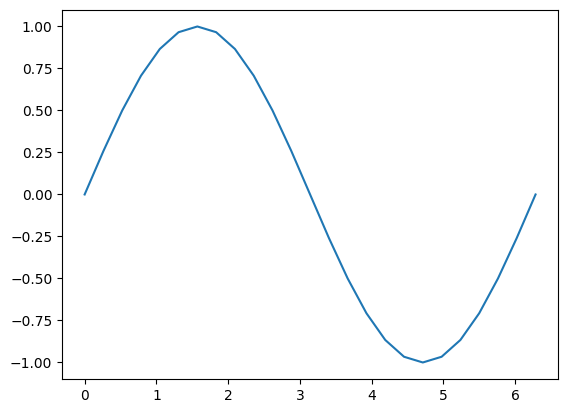

In [ ]:
plt.plot(a.detach(), b.detach())

In [ ]:
b.grad_fn

In [ ]:
c = 2 * b
c

tensor([ 0.0000e+00,  5.1764e-01,  1.0000e+00,  1.4142e+00,  1.7321e+00,
         1.9319e+00,  2.0000e+00,  1.9319e+00,  1.7321e+00,  1.4142e+00,
         1.0000e+00,  5.1764e-01, -1.7485e-07, -5.1764e-01, -1.0000e+00,
        -1.4142e+00, -1.7321e+00, -1.9319e+00, -2.0000e+00, -1.9319e+00,
        -1.7321e+00, -1.4142e+00, -1.0000e+00, -5.1764e-01,  3.4969e-07],
       grad_fn=<MulBackward0>)

In [ ]:
d = c + 1

In [ ]:
d

tensor([ 1.0000e+00,  1.5176e+00,  2.0000e+00,  2.4142e+00,  2.7321e+00,
         2.9319e+00,  3.0000e+00,  2.9319e+00,  2.7321e+00,  2.4142e+00,
         2.0000e+00,  1.5176e+00,  1.0000e+00,  4.8236e-01, -3.5763e-07,
        -4.1421e-01, -7.3205e-01, -9.3185e-01, -1.0000e+00, -9.3185e-01,
        -7.3205e-01, -4.1421e-01,  4.7684e-07,  4.8236e-01,  1.0000e+00],
       grad_fn=<AddBackward0>)

In [ ]:
out = d.sum()
out

tensor(25., grad_fn=<SumBackward0>)

In [ ]:
a1 = a.clone()
out1 = torch.sum((torch.sin(a1) * 2) + 1)
out1

tensor(25., grad_fn=<SumBackward0>)

In [ ]:
a = torch.linspace(0., 2. * math.pi, steps=25, requires_grad=True)
b = torch.sin(a)
c = b * 2
d = c + 1
out = d.sum()

In [ ]:
out

tensor(25., grad_fn=<SumBackward0>)

In [ ]:
d.grad_fn

In [ ]:
d.grad_fn.next_functions

((<MulBackward0 at 0x7d036ea86c50>, 0), (None, 0))

In [ ]:
d.grad_fn.next_functions[0][0].next_functions

((<SinBackward0 at 0x7d036e2b6890>, 0), (None, 0))

In [ ]:
d.grad_fn.next_functions[0][0].next_functions[0][0].next_functions

((<AccumulateGrad at 0x7d036eadb4c0>, 0),)

In [ ]:
d.grad_fn.next_functions[0][0].next_functions[0][0].next_functions[0][0].next_functions

()

In [ ]:
out.backward()

In [ ]:
print(a.grad)

tensor([ 2.0000e+00,  1.9319e+00,  1.7321e+00,  1.4142e+00,  1.0000e+00,
         5.1764e-01, -8.7423e-08, -5.1764e-01, -1.0000e+00, -1.4142e+00,
        -1.7321e+00, -1.9319e+00, -2.0000e+00, -1.9319e+00, -1.7321e+00,
        -1.4142e+00, -1.0000e+00, -5.1764e-01,  2.3850e-08,  5.1764e-01,
         1.0000e+00,  1.4142e+00,  1.7321e+00,  1.9319e+00,  2.0000e+00])


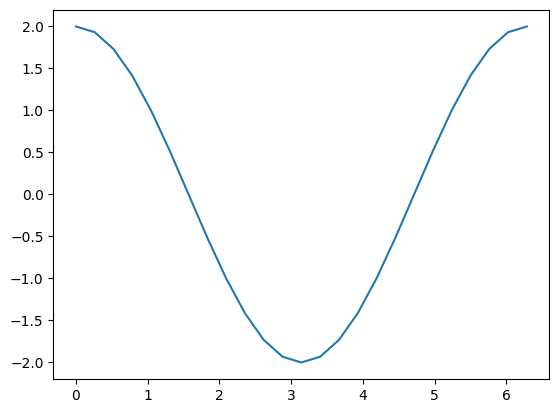

In [ ]:
plt.plot(a.detach(), a.grad.detach())

In [ ]:
# Autograd in training

In [ ]:
BATCH_SIZE = 16
DIM_IN = 1000
HIDDEN_SIZE = 100
DIM_OUT = 10

In [ ]:
class TinyModel(torch.nn.Module):
  def __init__(self):
    super(TinyModel, self).__init__()

    self.layer1 = torch.nn.Linear(DIM_IN, HIDDEN_SIZE)
    self.relu = torch.nn.ReLU()
    self.layer2 = torch.nn.Linear(HIDDEN_SIZE, DIM_OUT)

  def forward(self, x):
    x = self.layer1(x)
    x = self.relu(x)
    x = self.layer2(x)
    return x

In [ ]:
some_input = torch.randn(BATCH_SIZE, DIM_IN, requires_grad=False)
ideal_output = torch.randn(BATCH_SIZE, DIM_OUT, requires_grad=False)

In [ ]:
print(some_input.shape)
print(ideal_output.shape)

torch.Size([16, 1000])
torch.Size([16, 10])


In [ ]:
model = TinyModel()

In [ ]:
print(model.layer1.weight.grad_fn)
print(model.layer2.weight.grad_fn)

None
None


In [ ]:
print(model.layer1.weight.grad)
print(model.layer2.weight.grad)

None
None


In [ ]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

In [ ]:
prediction = model(some_input)

In [ ]:
loss = (prediction - ideal_output).pow(2).sum()
loss

tensor(222.5081, grad_fn=<SumBackward0>)

In [ ]:
loss.backward()

In [ ]:
print(model.layer1.weight.grad_fn)
print(model.layer2.weight.grad_fn)

None
None


In [ ]:
print(model.layer1.weight.grad[0][:10])
print(model.layer2.weight.grad[0][:10])

tensor([ 0.0836, -0.1019, -0.4869, -1.1858, -0.0239,  0.8601,  0.6124,  1.4691,
        -0.9550,  0.1788])
tensor([-6.8729, -7.1054, -2.6870, -3.7777, -6.8608, -9.5366, -2.7183, -1.7243,
        -1.0828, -4.0025])


In [ ]:
print(model.layer1.weight[0][:10])
print(model.layer2.weight[0][:10])

tensor([ 0.0301, -0.0221, -0.0104, -0.0267, -0.0154, -0.0286,  0.0153,  0.0216,
        -0.0187,  0.0132], grad_fn=<SliceBackward0>)
tensor([-0.0941, -0.0046, -0.0385, -0.0338, -0.0411, -0.0939, -0.0943,  0.0732,
         0.0838, -0.0901], grad_fn=<SliceBackward0>)


In [ ]:
optimizer.step()

In [ ]:
print(model.layer1.weight.grad[0][:10])
print(model.layer2.weight.grad[0][:10])

tensor([ 0.0836, -0.1019, -0.4869, -1.1858, -0.0239,  0.8601,  0.6124,  1.4691,
        -0.9550,  0.1788])
tensor([-6.8729, -7.1054, -2.6870, -3.7777, -6.8608, -9.5366, -2.7183, -1.7243,
        -1.0828, -4.0025])


In [ ]:
print(model.layer1.weight[0][:10])
print(model.layer2.weight[0][:10])

tensor([ 0.0300, -0.0220, -0.0099, -0.0255, -0.0154, -0.0294,  0.0146,  0.0201,
        -0.0178,  0.0130], grad_fn=<SliceBackward0>)
tensor([-0.0872,  0.0025, -0.0358, -0.0300, -0.0343, -0.0844, -0.0916,  0.0749,
         0.0849, -0.0861], grad_fn=<SliceBackward0>)


In [ ]:
optimizer.zero_grad(set_to_none=False)

In [ ]:
print(model.layer1.weight.grad[0][:10])
print(model.layer2.weight.grad[0][:10])

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


In [ ]:
a = torch.ones(2, 3, requires_grad=True) * 2
b = torch.ones(2, 3, requires_grad=True) * 3

In [ ]:
c = a + b

In [ ]:
c

tensor([[5., 5., 5.],
        [5., 5., 5.]], grad_fn=<AddBackward0>)

In [ ]:
c.grad

/tmp/ipython-input-2950652411.py:1: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:489.)
  c.grad


In [ ]:
a = torch.ones(2, 3, requires_grad=True)

In [ ]:
# Auto Grad Profiler

In [ ]:
import torch
device = torch.device('cpu')
run_on_gpu = False
if torch.cuda.is_available():
    device = torch.device('cuda')
    run_on_gpu = True

In [ ]:
x = torch.randn(2, 3, requires_grad=True, device="cuda")
y = torch.rand(2, 3, requires_grad=True, device="cuda")
z = torch.ones(2, 3, requires_grad=True, device="cuda")

In [ ]:
with torch.autograd.profiler.profile(use_cuda=run_on_gpu) as prf:
  for _ in range(1000):
    z = (z / x) * y

/tmp/ipython-input-2690598585.py:1: FutureWarning: The attribute `use_cuda` will be deprecated soon, please use ``use_device = 'cuda'`` instead.
  with torch.autograd.profiler.profile(use_cuda=run_on_gpu) as prf:


In [ ]:
print(prf.key_averages().table(sort_by='self_cpu_time_total'))

-------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                     Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
         cudaLaunchKernel        60.85%      51.068ms        60.85%      51.068ms      25.534us       0.000us         0.00%       0.000us       0.000us          2000  
                aten::div        17.69%      14.843ms        49.36%      41.423ms      41.423us      45.168ms        53.70%      45.168ms      45.168us          1000  
                aten::mul        12.94%      10.862ms        42.12%      35.350ms      35.350us      38.936ms        46.30%      38.936ms      38.936us        

In [ ]:
run_on_gpu

True

tensor([[-2.3282, -0.3277, -0.8122],
        [-0.3420,  1.1712,  0.7642]], device='cuda:0')

tensor([[-2.3282, -0.3277, -0.8122],
        [-0.3420,  1.1712,  0.7642]], device='cuda:0', requires_grad=True)